In [70]:
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns

#l'idée centrale de ce TP est d'apprendre à exploiter un **index temporel** (`DatetimeIndex`) pandas :  
#resampling, filtrage par date, extraction d'attributs (heure, jour de semaine), pivot...  
#c'est ce qui permet ensuite de repérer des motifs (jours de semaine vs week-end) sans écrire de boucle

URL = "https://data.seattle.gov/api/views/65db-xm6k/rows.csv?accessType=DOWNLOAD"

# on a déja le fichier en local
local_file = "data/fremont.csv"

from pathlib import Path

if Path(local_file).exists():
    print(f"le fichier {local_file} est déjà là")
else:
    print(f"allons chercher le fichier {local_file}")

    import requests
    req = requests.get(URL)
    print(req.status_code)

    with open(local_file, 'w') as writer:
        writer.write(req.text)


# Chargement version naïve
data = pd.read_csv(local_file)
data.shape

data.head()

le fichier data/fremont.csv est déjà là


,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
0,08/01/2022 12:00:00 AM,23.0,7.0,16.0
1,08/01/2022 01:00:00 AM,12.0,5.0,7.0
2,08/01/2022 02:00:00 AM,3.0,0.0,3.0
3,08/01/2022 03:00:00 AM,5.0,2.0,3.0
4,08/01/2022 04:00:00 AM,10.0,2.0,8.0


In [71]:
print(str(len(df)) + "avant drop")
data.drop_duplicates(inplace=True)
print(str(len(df)) + "après drop")

87600avant drop
87600après drop


In [72]:
# Echauffement
sample_dates = pd.to_datetime([
    "2024-01-15 08:00:00",
    "2024-01-20 17:30:00",
    "2024-02-03 12:00:00",
])

#1
print(type(sample_dates))
#2
print(sample_dates.date)
print(sample_dates.time)
print(sample_dates.dayofweek)
#3
print(sample_dates >= "2024-01-20")
print(sample_dates[(sample_dates >= "2024-01-20")])
#4
#print(sample_dates["2024-01-01" >= sample_dates and sample_dates >= "2024-01-31"])


<class 'pandas.DatetimeIndex'>
[datetime.date(2024, 1, 15) datetime.date(2024, 1, 20)
 datetime.date(2024, 2, 3)]
[datetime.time(8, 0) datetime.time(17, 30) datetime.time(12, 0)]
Index([0, 5, 5], dtype='int32')
[False  True  True]
DatetimeIndex(['2024-01-20 17:30:00', '2024-02-03 12:00:00'], dtype='datetime64[us]', freq=None)


In [73]:
# Parser les dates
# intéressant aussi, pour voir notamment les points manquants
data.info()
data.dtypes

#Definition des dates comme index
data.index=pd.to_datetime(data.Date, format= '%m/%d/%Y %I:%M:%S %p')
data.drop('Date', axis=1, inplace=True)
data #affichage du nouveau tableau

<class 'pandas.DataFrame'>
RangeIndex: 87600 entries, 0 to 87599
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          87600 non-null  str    
 1   Fremont Bridge Total          87586 non-null  float64
 2   Fremont Bridge East Sidewalk  87586 non-null  float64
 3   Fremont Bridge West Sidewalk  87586 non-null  float64
dtypes: float64(3), str(1)
memory usage: 2.7 MB


,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0
...,...,...,...
2022-09-30 19:00:00,168.0,57.0,111.0
2022-09-30 20:00:00,73.0,33.0,40.0
2022-09-30 21:00:00,69.0,30.0,39.0


In [74]:
# Renommons les colonnes
data.columns = ['Total', 'East', 'West']

# Données manquantes et extension types
data.isna().any(axis=1)

Date
2022-08-01 00:00:00    False
2022-08-01 01:00:00    False
2022-08-01 02:00:00    False
2022-08-01 03:00:00    False
2022-08-01 04:00:00    False
                       ...  
2022-09-30 19:00:00    False
2022-09-30 20:00:00    False
2022-09-30 21:00:00    False
2022-09-30 22:00:00    False
2022-09-30 23:00:00    False
Length: 87600, dtype: bool

<Axes: xlabel='Date'>

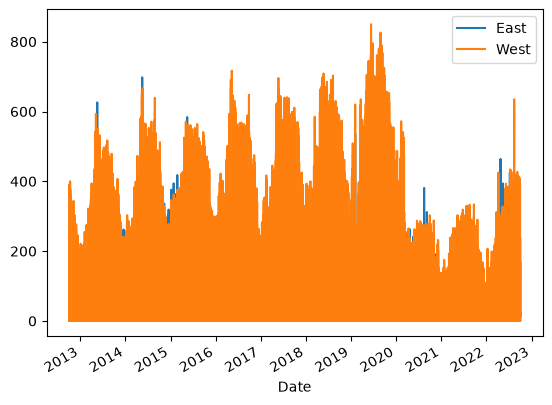

In [ ]:
# A quoi ça ressemble : un premier jet, pas terrible du tout
data[['East', 'West']].plot()

In [ ]:
# Changer la fréquence temporelle